In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (6,965 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126111 files and dire

하이퍼파라미터 튜닝을 시작합니다...
Fitting 3 folds for each of 100 candidates, totalling 300 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004146 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2762
[LightGBM] [Info] Number of data points in the train set: 20664, number of used features: 39
[LightGBM] [Info] Start training from score 25682.064508
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



--- 최종 모델 평가 결과 ---
최적 하이퍼파라미터: {'lgbm__colsample_bytree': np.float64(0.4381070977540008), 'lgbm__learning_rate': np.float64(0.01941093381799569), 'lgbm__max_depth': 14, 'lgbm__min_child_samples': 5, 'lgbm__n_estimators': 504, 'lgbm__num_leaves': 74, 'lgbm__subsample': np.float64(0.918833425753032)}
Test Set RMSE: 65534.4118
Test Set R²: 0.3164
Test Set SMAPE: 144.8353 %
Test Set F1-Score (Threshold: 622): 0.7366

--- SHAP 분석 및 시각화를 시작합니다 ---


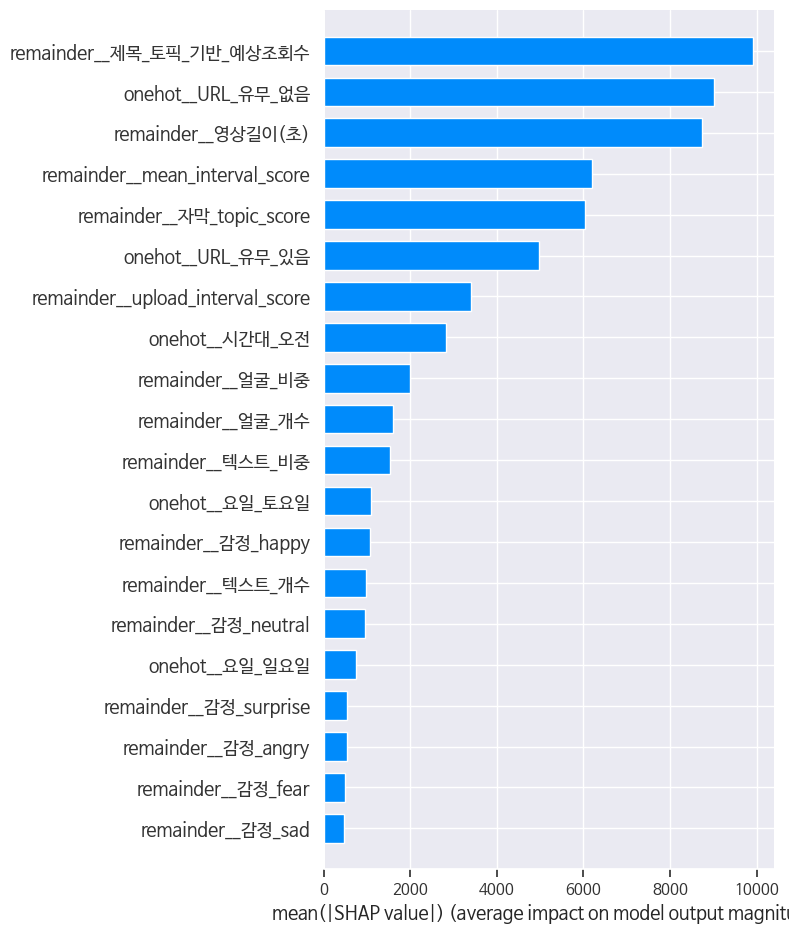

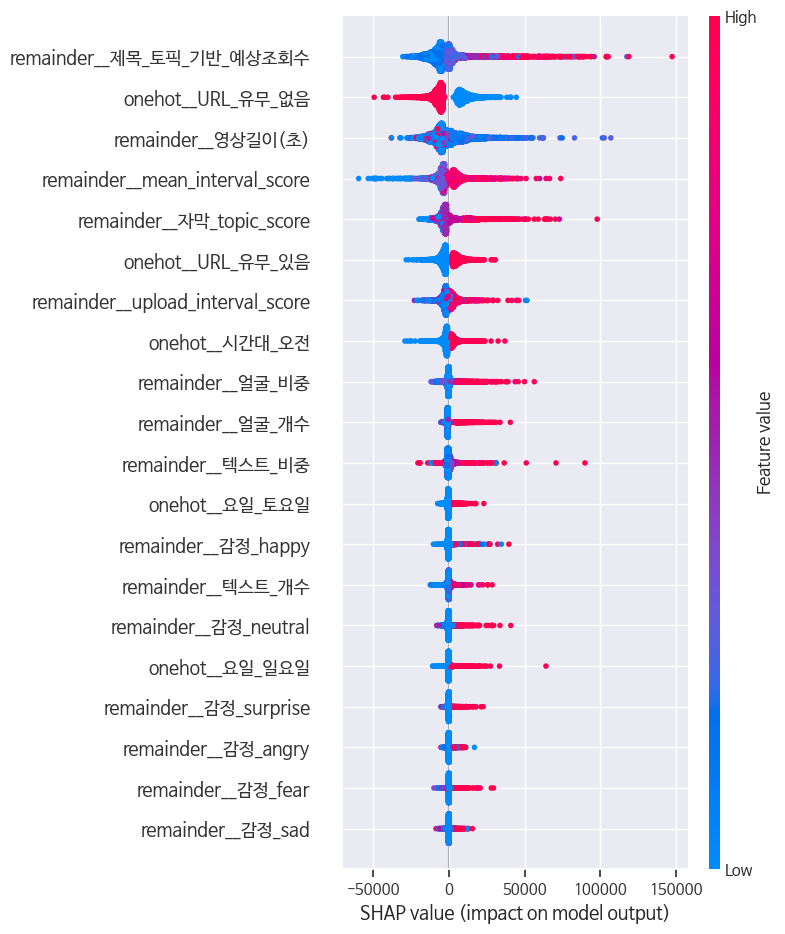

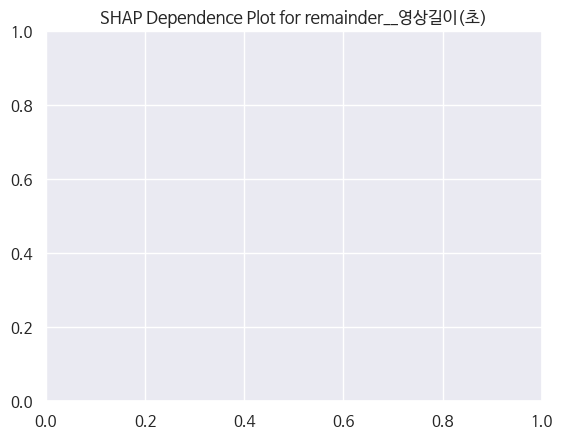

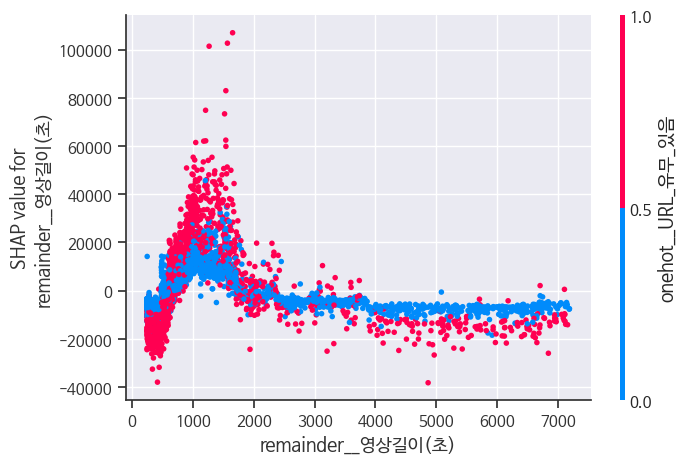

DimensionError: Length of features is not equal to the length of shap_values!

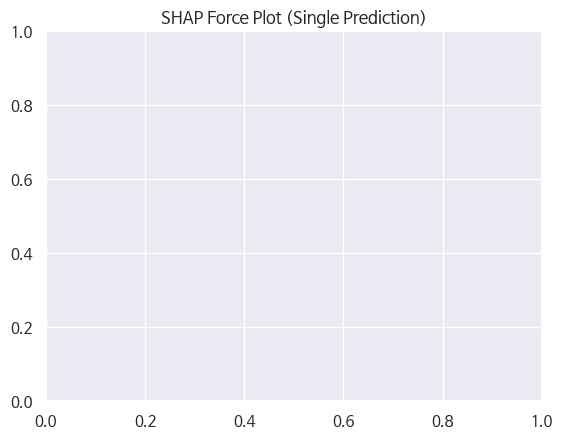

In [ ]:


import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint, uniform
from sklearn.metrics import mean_squared_error, r2_score, f1_score
from scipy.stats import randint, uniform

# ==============================================================================
# 2. 데이터 로드 및 전처리
# ==============================================================================
# Colab에 'final_data.csv' 파일을 업로드해야 합니다.
try:
    file_path = 'final_data.csv'
    df = pd.read_csv(file_path, encoding='cp949')
except FileNotFoundError:
    print("'final_data.csv' 파일을 Colab 환경에 업로드해주세요.")
    # 예시를 위해 가상 데이터프레임 생성 (실제 실행 시 위 코드로 대체)
    data = {
        '영상길이(초)': np.random.randint(60, 1200, 1000), '자막_topic_score': np.random.rand(1000),
        '텍스트_개수': np.random.randint(0, 50, 1000), '텍스트_비중': np.random.rand(1000),
        '얼굴_개수': np.random.randint(0, 5, 1000), '얼굴_비중': np.random.rand(1000),
        '감정_angry': np.random.rand(1000), '감정_disgust': np.random.rand(1000),
        '감정_fear': np.random.rand(1000), '감정_happy': np.random.rand(1000),
        '감정_sad': np.random.rand(1000), '감정_surprise': np.random.rand(1000),
        '감정_neutral': np.random.rand(1000), 'upload_interval_score': np.random.rand(1000),
        'mean_interval_score': np.random.rand(1000), '제목_평균조회수': np.random.randint(1000, 100000, 1000),
        '제목_토픽_기반_예상조회수': np.random.randint(1000, 100000, 1000),
        '요일': np.random.choice(['월', '화', '수', '목', '금', '토', '일'], 1000),
        '업로드_시각': np.random.randint(0, 23, 1000).astype(str),
        '주요_감정': np.random.choice(['happy', 'neutral', 'surprise'], 1000),
        '얼굴_감지여부': np.random.choice([0, 1], 1000),
        '챕터유무': np.random.choice([True, False], 1000),
        'URL_유무': np.random.choice([True, False], 1000),
        '조회수': np.random.randint(500, 500000, 1000)
    }
    df = pd.DataFrame(data)
    print("파일을 찾을 수 없어 가상 데이터로 실행합니다.")


def categorize_hour(hour):
    try:
        h = int(hour)
        if 6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else: return '새벽'
    except (ValueError, TypeError):
        return np.nan

df['시간대'] = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)
df['URL_유무'] = df['URL_유무'].map({True:'있음', False:'없음'})

feature_cols = [
    '영상길이(초)', '자막_topic_score',
    '텍스트_개수', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_평균조회수', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정', '얼굴_감지여부',
    '챕터유무', 'URL_유무'
]
target_col = '조회수'
categorical_features = ['요일', '시간대', '주요_감정', 'URL_유무']

# 결측치 처리 후 데이터 분할
df_clean = df[feature_cols + [target_col]].dropna()
X = df_clean[feature_cols]
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================================================================
# 3. 하이퍼파라미터 튜닝 및 모델 학습
# ==============================================================================
preprocessor = ColumnTransformer(
    [('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(random_state=42))
])

param_distributions = {
    'lgbm__n_estimators': randint(100, 1300),
    'lgbm__learning_rate': uniform(0.001, 0.5),
    'lgbm__max_depth': randint(8, 15),
    'lgbm__num_leaves': randint(20, 200),
    'lgbm__min_child_samples': randint(5, 50),
    'lgbm__subsample': uniform(0.4, 0.6),
    'lgbm__colsample_bytree': uniform(0.4, 0.6),
}

# n_iter 값을 줄이면 더 빠르게 테스트할 수 있습니다. (예: n_iter=20)
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=100,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("하이퍼파라미터 튜닝을 시작합니다...")
search.fit(X_train, y_train)

# ==============================================================================
# 4. 최적 모델 평가 (RMSE, R², SMAPE)
# ==============================================================================
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

# SMAPE 함수 정의
def smape(y_true, y_pred):
    return np.mean((2 * np.abs(y_pred - y_true)) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
smape_score = smape(y_test, y_pred)

# --- F1 스코어 계산 (이진 분류로 변환) ---
# 중앙값을 기준으로 '높은 조회수'(1)와 '낮은 조회수'(0)로 분류
threshold = y_test.median()
y_test_binary = (y_test >= threshold).astype(int)
y_pred_binary = (y_pred >= threshold).astype(int)
f1 = f1_score(y_test_binary, y_pred_binary)

print("\n--- 최종 모델 평가 결과 ---")
print(f"최적 하이퍼파라미터: {search.best_params_}")
print(f"Test Set RMSE: {rmse:.4f}")
print(f"Test Set R²: {r2:.4f}")
print(f"Test Set SMAPE: {smape_score:.4f} %")
print(f"Test Set F1-Score (Threshold: {threshold:.0f}): {f1:.4f}")


# ==============================================================================
# 5. SHAP 분석 및 시각화
# ==============================================================================
print("\n--- SHAP 분석 및 시각화를 시작합니다 ---")

# 파이프라인에서 전처리기와 모델 추출
preprocessor_fitted = best_model.named_steps['prep']
lgbm_model_fitted = best_model.named_steps['lgbm']

# 테스트 데이터를 원핫인코딩 등 변환
X_test_transformed = preprocessor_fitted.transform(X_test)

# 변환된 피처 이름 가져오기
feature_names_transformed = preprocessor_fitted.get_feature_names_out()

# SHAP Explainer 생성 및 SHAP 값 계산
explainer = shap.TreeExplainer(lgbm_model_fitted)
shap_values = explainer.shap_values(X_test_transformed)

# SHAP 값과 변환된 데이터를 DataFrame으로 만들어 확인 (선택 사항)
# X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names_transformed)
# print(X_test_transformed_df.head())


### --- 다양한 SHAP 시각화 --- ###

# 1. Summary Plot (bar) : 전체 변수 중요도
plt.figure(figsize=(10, 8))
plt.title('SHAP Summary Plot (Feature Importance)')
shap.summary_plot(shap_values, X_test_transformed, plot_type="bar", feature_names=feature_names_transformed)
plt.show()

# 2. Summary Plot (dot) : 변수 값에 따른 영향력 분포
plt.figure(figsize=(10, 8))
plt.title('SHAP Summary Plot (Impact Distribution)')
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names_transformed)
plt.show()

# 3. Dependence Plot : 특정 변수와 다른 변수 간의 상호작용
# 예시: '영상길이(초)' 변수에 대한 의존도 플롯
# 'remainder__' 접두사는 ColumnTransformer에서 수치형 변수에 자동으로 붙는 이름입니다.
# 다른 변수를 보고 싶다면 `feature_to_plot` 값을 변경하세요.
try:
    feature_to_plot = 'remainder__영상길이(초)'
    plt.title(f'SHAP Dependence Plot for {feature_to_plot}')
    shap.dependence_plot(feature_to_plot, shap_values, X_test_transformed, feature_names=feature_names_transformed)
    plt.show()
except Exception as e:
    print(f"Dependence Plot 생성 실패: {e}. 변수명을 확인하세요.")
    print(f"사용 가능한 변수명 예시: {feature_names_transformed[:5]}")


# 4. Force Plot (단일 예측) : 첫 번째 테스트 데이터 예측에 대한 설명
# Javascript 기반이라 Colab에서 바로 렌더링 됩니다.
plt.title('SHAP Force Plot (Single Prediction)')
shap.initjs() # Javascript 초기화
display(shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:]))


# 5. Force Plot (전체 데이터) : 모든 테스트 데이터에 대한 설명 (상호작용 플롯)
# 데이터가 크면 로딩이 오래 걸릴 수 있습니다.
# HTML로 저장하여 보는 것을 권장합니다.
# force_plot_html = shap.force_plot(explainer.expected_value, shap_values, X_test_transformed_df)
# shap.save_html("force_plot.html", force_plot_html)
# print("전체 데이터에 대한 Force Plot이 'force_plot.html'로 저장되었습니다.")
# 여기서는 시각화를 위해 일부 샘플만 사용합니다.
try:
    plt.title('SHAP Force Plot (Multiple Predictions)')
    display(shap.force_plot(explainer.expected_value, shap_values[:100], X_test.iloc[:100]))
except Exception as e:
    print(f"전체 Force Plot 생성 실패: {e}")


# 6. Decision Plot : 예측 결정 과정 시각화
# 특정 샘플(예: 첫 20개)의 예측 과정을 보여줍니다.
plt.title('SHAP Decision Plot')
shap.decision_plot(explainer.expected_value, shap_values[:20], feature_names=list(feature_names_transformed))
plt.show()


하이퍼파라미터 튜닝을 시작합니다...
Fitting 3 folds for each of 100 candidates, totalling 300 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004463 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2762
[LightGBM] [Info] Number of data points in the train set: 20664, number of used features: 39
[LightGBM] [Info] Start training from score 25682.064508
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



--- 최종 모델 평가 결과 ---
최적 하이퍼파라미터: {'lgbm__colsample_bytree': np.float64(0.4381070977540008), 'lgbm__learning_rate': np.float64(0.01941093381799569), 'lgbm__max_depth': 14, 'lgbm__min_child_samples': 5, 'lgbm__n_estimators': 504, 'lgbm__num_leaves': 74, 'lgbm__subsample': np.float64(0.918833425753032)}
Test Set RMSE: 65534.4118
Test Set R²: 0.3164
Test Set SMAPE: 144.8353 %
Test Set F1-Score (Threshold: 622): 0.7366

--- SHAP 분석 및 시각화를 시작합니다 ---


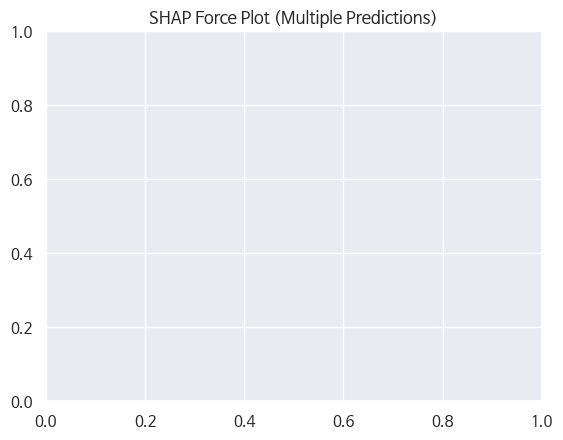

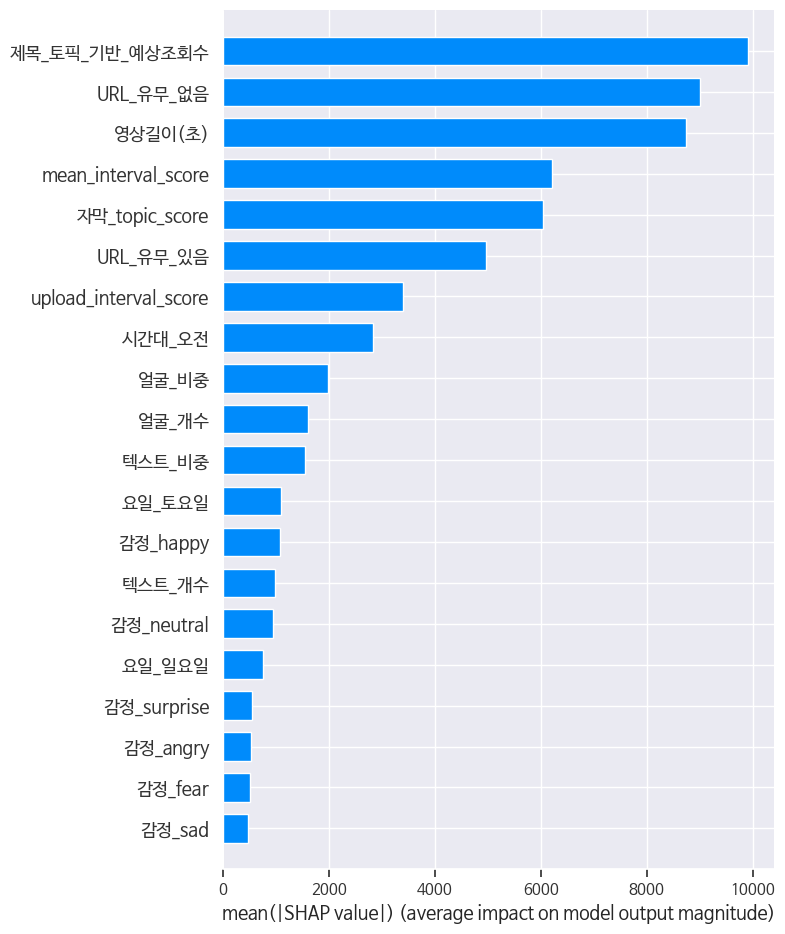

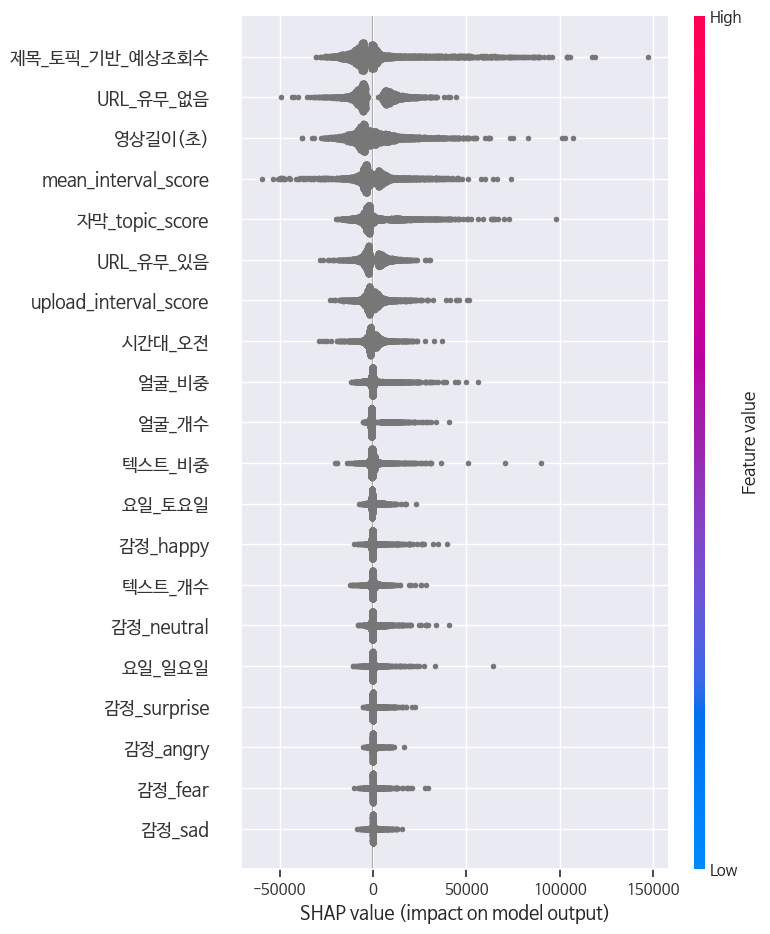

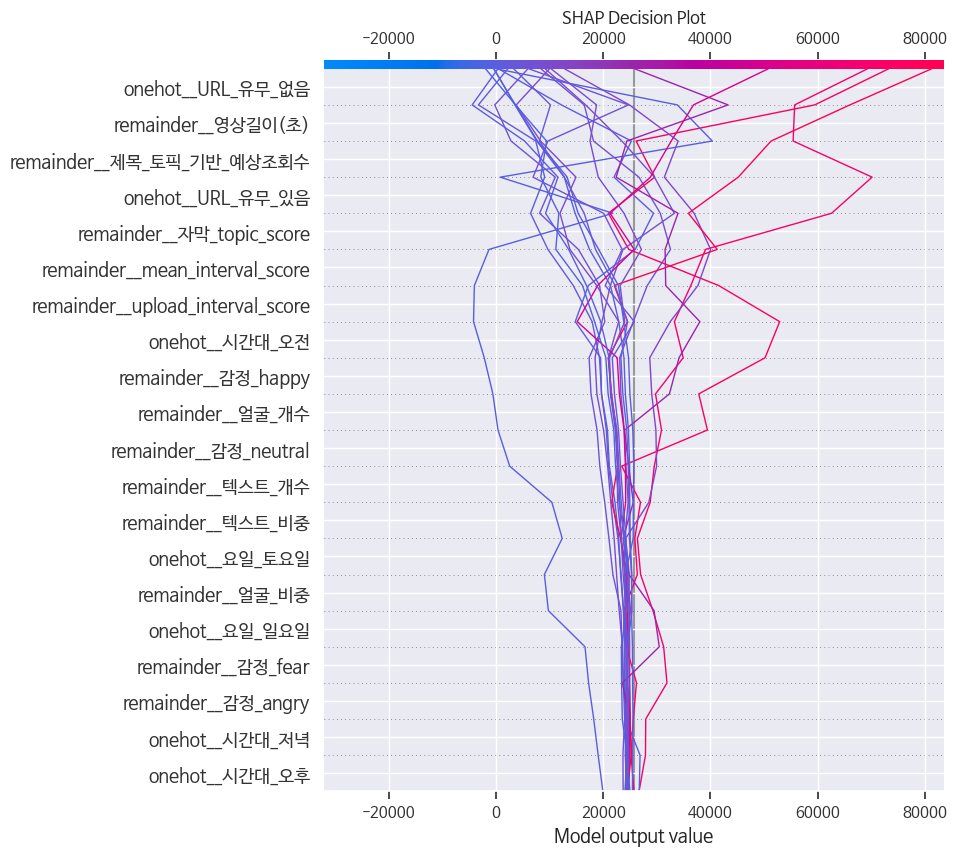

In [ ]:
#수정버전


import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint, uniform
from sklearn.metrics import mean_squared_error, r2_score, f1_score
from scipy.stats import randint, uniform

# ==============================================================================
# 2. 데이터 로드 및 전처리
# ==============================================================================
# Colab에 'final_data.csv' 파일을 업로드해야 합니다.
try:
    file_path = 'final_data.csv'
    df = pd.read_csv(file_path, encoding='cp949')
except FileNotFoundError:
    print("'final_data.csv' 파일을 Colab 환경에 업로드해주세요.")
    # 예시를 위해 가상 데이터프레임 생성 (실제 실행 시 위 코드로 대체)
    data = {
        '영상길이(초)': np.random.randint(60, 1200, 1000), '자막_topic_score': np.random.rand(1000),
        '텍스트_개수': np.random.randint(0, 50, 1000), '텍스트_비중': np.random.rand(1000),
        '얼굴_개수': np.random.randint(0, 5, 1000), '얼굴_비중': np.random.rand(1000),
        '감정_angry': np.random.rand(1000), '감정_disgust': np.random.rand(1000),
        '감정_fear': np.random.rand(1000), '감정_happy': np.random.rand(1000),
        '감정_sad': np.random.rand(1000), '감정_surprise': np.random.rand(1000),
        '감정_neutral': np.random.rand(1000), 'upload_interval_score': np.random.rand(1000),
        'mean_interval_score': np.random.rand(1000), '제목_평균조회수': np.random.randint(1000, 100000, 1000),
        '제목_토픽_기반_예상조회수': np.random.randint(1000, 100000, 1000),
        '요일': np.random.choice(['월', '화', '수', '목', '금', '토', '일'], 1000),
        '업로드_시각': np.random.randint(0, 23, 1000).astype(str),
        '주요_감정': np.random.choice(['happy', 'neutral', 'surprise'], 1000),
        '얼굴_감지여부': np.random.choice([0, 1], 1000),
        '챕터유무': np.random.choice([True, False], 1000),
        'URL_유무': np.random.choice([True, False], 1000),
        '조회수': np.random.randint(500, 500000, 1000)
    }
    df = pd.DataFrame(data)
    print("파일을 찾을 수 없어 가상 데이터로 실행합니다.")


def categorize_hour(hour):
    try:
        h = int(hour)
        if 6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else: return '새벽'
    except (ValueError, TypeError):
        return np.nan

df['시간대'] = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)
df['URL_유무'] = df['URL_유무'].map({True:'있음', False:'없음'})

feature_cols = [
    '영상길이(초)', '자막_topic_score',
    '텍스트_개수', '텍스트_비중',
    '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy',
    '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score',
    '제목_평균조회수', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정', '얼굴_감지여부',
    '챕터유무', 'URL_유무'
]
target_col = '조회수'
categorical_features = ['요일', '시간대', '주요_감정', 'URL_유무']

# 결측치 처리 후 데이터 분할
df_clean = df[feature_cols + [target_col]].dropna()
X = df_clean[feature_cols]
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================================================================
# 3. 하이퍼파라미터 튜닝 및 모델 학습
# ==============================================================================
preprocessor = ColumnTransformer(
    [('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(random_state=42))
])

param_distributions = {
    'lgbm__n_estimators': randint(100, 1300),
    'lgbm__learning_rate': uniform(0.001, 0.5),
    'lgbm__max_depth': randint(8, 15),
    'lgbm__num_leaves': randint(20, 200),
    'lgbm__min_child_samples': randint(5, 50),
    'lgbm__subsample': uniform(0.4, 0.6),
    'lgbm__colsample_bytree': uniform(0.4, 0.6),
}

# n_iter 값을 줄이면 더 빠르게 테스트할 수 있습니다. (예: n_iter=20)
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=100,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("하이퍼파라미터 튜닝을 시작합니다...")
search.fit(X_train, y_train)

# ==============================================================================
# 4. 최적 모델 평가 (RMSE, R², SMAPE)
# ==============================================================================
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

# SMAPE 함수 정의
def smape(y_true, y_pred):
    return np.mean((2 * np.abs(y_pred - y_true)) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
smape_score = smape(y_test, y_pred)

# --- F1 스코어 계산 (이진 분류로 변환) ---
# 중앙값을 기준으로 '높은 조회수'(1)와 '낮은 조회수'(0)로 분류
threshold = y_test.median()
y_test_binary = (y_test >= threshold).astype(int)
y_pred_binary = (y_pred >= threshold).astype(int)
f1 = f1_score(y_test_binary, y_pred_binary)

print("\n--- 최종 모델 평가 결과 ---")
print(f"최적 하이퍼파라미터: {search.best_params_}")
print(f"Test Set RMSE: {rmse:.4f}")
print(f"Test Set R²: {r2:.4f}")
print(f"Test Set SMAPE: {smape_score:.4f} %")
print(f"Test Set F1-Score (Threshold: {threshold:.0f}): {f1:.4f}")


# ==============================================================================
# 5. SHAP 분석 및 시각화 (수정된 버전)
# ==============================================================================
print("\n--- SHAP 분석 및 시각화를 시작합니다 ---")

# 파이프라인에서 전처리기와 모델 추출
preprocessor_fitted = best_model.named_steps['prep']
lgbm_model_fitted = best_model.named_steps['lgbm']

# 테스트 데이터를 원핫인코딩 등 변환
X_test_transformed = preprocessor_fitted.transform(X_test)

# 변환된 피처 이름 가져오기
feature_names_transformed = preprocessor_fitted.get_feature_names_out()

# 변환된 데이터를 DataFrame으로 만들어주면 다루기 용이합니다.
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names_transformed)

# SHAP Explainer 생성 및 SHAP 값 계산
explainer = shap.TreeExplainer(lgbm_model_fitted)
shap_values = explainer.shap_values(X_test_transformed)


### --- 요청사항: 피처 이름에서 접두사 제거 --- ###
# 'remainder__'와 'onehot__' 접두사를 제거하는 함수 정의
def clean_feature_names(feature_names):
    cleaned_names = []
    for name in feature_names:
        if name.startswith('remainder__'):
            cleaned_names.append(name.replace('remainder__', ''))
        elif name.startswith('onehot__'):
            cleaned_names.append(name.replace('onehot__', ''))
        else:
            cleaned_names.append(name)
    return cleaned_names

# 기존 변수명에서 접두어 제거
cleaned_feature_names = clean_feature_names(feature_names_transformed)


### --- 오류 수정 및 피처 이름 정리하여 Force Plot 재생성 --- ###

# 4. Force Plot (단일 예측) : 첫 번째 테스트 데이터 예측에 대한 설명
# [오류 수정] X_test.iloc[0,:] -> X_test_transformed_df.iloc[0]
# [이름 변경] feature_names=cleaned_feature_names 추가
plt.title('SHAP Force Plot (Single Prediction)')
shap.initjs() # Javascript 초기화
display(shap.force_plot(
    explainer.expected_value,
    shap_values[0,:],
    X_test_transformed_df.iloc[0,:], # 수정: 전처리된 데이터 사용
    feature_names=cleaned_feature_names # 추가: 정리된 피처 이름 사용
))


# 5. Force Plot (전체 데이터) : 모든 테스트 데이터에 대한 설명 (상호작용 플롯)
# 데이터가 크면 로딩이 오래 걸릴 수 있으므로 일부 샘플만 사용합니다.
try:
    plt.title('SHAP Force Plot (Multiple Predictions)')
    display(shap.force_plot(
        explainer.expected_value,
        shap_values[:100],
        X_test_transformed_df.iloc[:100,:], # 수정: 전처리된 데이터 사용
        feature_names=cleaned_feature_names # 추가: 정리된 피처 이름 사용
    ))
except Exception as e:
    print(f"전체 Force Plot 생성 실패: {e}")

# 아래의 다른 SHAP 시각화들도 정리된 피처 이름을 사용하고 싶다면,
# 기존 'feature_names_transformed' 대신 'cleaned_feature_names' 변수를 사용하시면 됩니다.

# 예시: Summary Plot (bar)
plt.figure(figsize=(10, 8))
plt.title('SHAP Summary Plot (Feature Importance) - Cleaned Names')
shap.summary_plot(shap_values, X_test_transformed, plot_type="bar", feature_names=cleaned_feature_names)
plt.show()

# SHAP Summary Plot (산점도)
plt.figure(figsize=(10, 8))
plt.title('SHAP Summary Plot (산점도) - Cleaned Names')
# plot_type 인자를 제거하여 기본값인 산점도(dot plot)로 출력합니다.
# X_test_transformed 대신 DataFrame 형태인 X_test_transformed_df를 사용하면 색상으로 피처 값을 더 잘 표현할 수 있습니다.
shap.summary_plot(shap_values, X_test_transformed_df, feature_names=cleaned_feature_names)
plt.show()


# 6. Decision Plot : 예측 결정 과정 시각화
# 특정 샘플(예: 첫 20개)의 예측 과정을 보여줍니다.
plt.title('SHAP Decision Plot')
shap.decision_plot(explainer.expected_value, shap_values[:20], feature_names=list(feature_names_transformed))
plt.show()


하이퍼파라미터 튜닝을 시작합니다...
Fitting 3 folds for each of 100 candidates, totalling 300 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006221 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2762
[LightGBM] [Info] Number of data points in the train set: 20664, number of used features: 39
[LightGBM] [Info] Start training from score 25682.064508
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



--- 최종 모델 평가 결과 ---
최적 하이퍼파라미터: {'lgbm__colsample_bytree': np.float64(0.4381070977540008), 'lgbm__learning_rate': np.float64(0.01941093381799569), 'lgbm__max_depth': 14, 'lgbm__min_child_samples': 5, 'lgbm__n_estimators': 504, 'lgbm__num_leaves': 74, 'lgbm__subsample': np.float64(0.918833425753032)}
Test Set RMSE: 65534.4118
Test Set R²: 0.3164
Test Set SMAPE: 144.8353 %
Test Set F1-Score (Threshold: 622): 0.7366

--- SHAP 분석 및 시각화를 시작합니다 ---


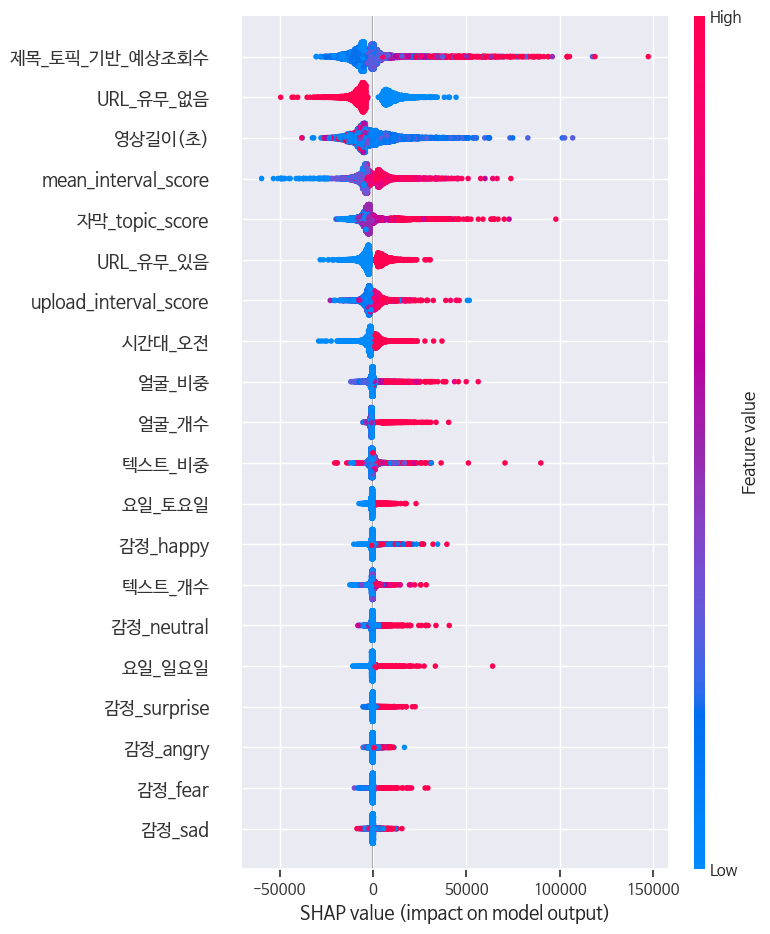

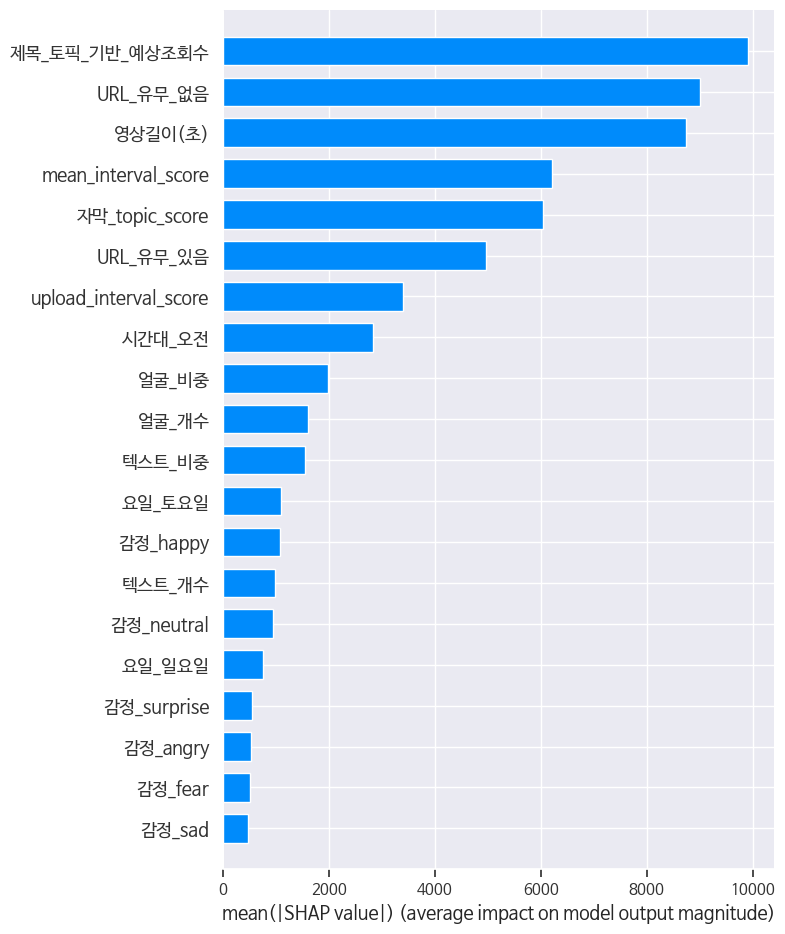

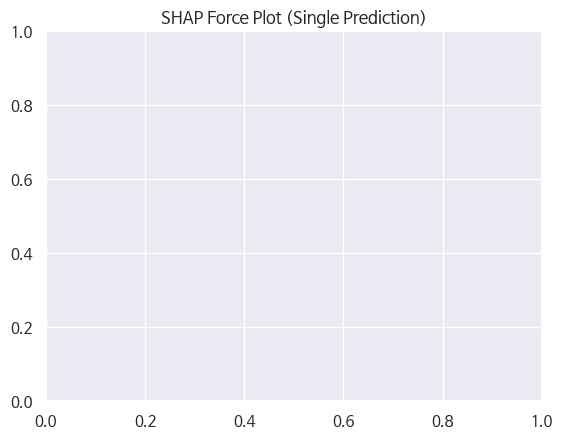

In [ ]:
# ==============================================================================
# 1. 라이브러리 임포트
# ==============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from IPython.display import display

# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, f1_score
from scipy.stats import randint, uniform

# ==============================================================================
# 2. 데이터 로드 및 전처리
# ==============================================================================
try:
    file_path = 'final_data.csv'
    df = pd.read_csv(file_path, encoding='cp949')
except FileNotFoundError:
    print("'final_data.csv' 파일을 Colab 환경에 업로드해주세요.")
    # 예시를 위해 가상 데이터프레임 생성
    data = {
        '영상길이(초)': np.random.randint(60, 1200, 1000), '자막_topic_score': np.random.rand(1000),
        '텍스트_개수': np.random.randint(0, 50, 1000), '텍스트_비중': np.random.rand(1000),
        '얼굴_개수': np.random.randint(0, 5, 1000), '얼굴_비중': np.random.rand(1000),
        '감정_angry': np.random.rand(1000), '감정_disgust': np.random.rand(1000),
        '감정_fear': np.random.rand(1000), '감정_happy': np.random.rand(1000),
        '감정_sad': np.random.rand(1000), '감정_surprise': np.random.rand(1000),
        '감정_neutral': np.random.rand(1000), 'upload_interval_score': np.random.rand(1000),
        'mean_interval_score': np.random.rand(1000), '제목_평균조회수': np.random.randint(1000, 100000, 1000),
        '제목_토픽_기반_예상조회수': np.random.randint(1000, 100000, 1000),
        '요일': np.random.choice(['월', '화', '수', '목', '금', '토', '일'], 1000),
        '업로드_시각': np.random.randint(0, 23, 1000).astype(str),
        '주요_감정': np.random.choice(['happy', 'neutral', 'surprise'], 1000),
        '얼굴_감지여부': np.random.choice([0, 1], 1000),
        '챕터유무': np.random.choice([True, False], 1000),
        'URL_유무': np.random.choice([True, False], 1000),
        '조회수': np.random.randint(500, 500000, 1000)
    }
    df = pd.DataFrame(data)
    print("파일을 찾을 수 없어 가상 데이터로 실행합니다.")


def categorize_hour(hour):
    try:
        h = int(hour)
        if 6 <= h < 12: return '오전'
        elif 12 <= h < 18: return '오후'
        elif 18 <= h < 24: return '저녁'
        else: return '새벽'
    except (ValueError, TypeError):
        return np.nan

df['시간대'] = df['업로드_시각'].apply(categorize_hour)
df['얼굴_감지여부'] = df['얼굴_감지여부'].astype(int)
df['URL_유무'] = df['URL_유무'].map({True:'있음', False:'없음'})

feature_cols = [
    '영상길이(초)', '자막_topic_score', '텍스트_개수', '텍스트_비중', '얼굴_개수', '얼굴_비중',
    '감정_angry', '감정_disgust', '감정_fear', '감정_happy', '감정_sad', '감정_surprise', '감정_neutral',
    'upload_interval_score', 'mean_interval_score', '제목_평균조회수', '제목_토픽_기반_예상조회수',
    '요일', '시간대', '주요_감정', '얼굴_감지여부', '챕터유무', 'URL_유무'
]
target_col = '조회수'
categorical_features = ['요일', '시간대', '주요_감정', 'URL_유무']

df_clean = df[feature_cols + [target_col]].dropna()
X = df_clean[feature_cols]
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==============================================================================
# 3. 하이퍼파라미터 튜닝 및 모델 학습
# ==============================================================================
preprocessor = ColumnTransformer(
    [('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMRegressor(random_state=42))
])

param_distributions = {
    'lgbm__n_estimators': randint(100, 1300),
    'lgbm__learning_rate': uniform(0.001, 0.5),
    'lgbm__max_depth': randint(8, 15),
    'lgbm__num_leaves': randint(20, 200),
    'lgbm__min_child_samples': randint(5, 50),
    'lgbm__subsample': uniform(0.4, 0.6),
    'lgbm__colsample_bytree': uniform(0.4, 0.6),
}

search = RandomizedSearchCV(
    pipeline, param_distributions=param_distributions, n_iter=100,
    scoring='neg_root_mean_squared_error', cv=3, verbose=2, n_jobs=-1, random_state=42
)

print("하이퍼파라미터 튜닝을 시작합니다...")
search.fit(X_train, y_train)

# ==============================================================================
# 4. 최적 모델 평가
# ==============================================================================
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

def smape(y_true, y_pred):
    return np.mean((2 * np.abs(y_pred - y_true)) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
smape_score = smape(y_test, y_pred)

threshold = y_test.median()
y_test_binary = (y_test >= threshold).astype(int)
y_pred_binary = (y_pred >= threshold).astype(int)
f1 = f1_score(y_test_binary, y_pred_binary)

print("\n--- 최종 모델 평가 결과 ---")
print(f"최적 하이퍼파라미터: {search.best_params_}")
print(f"Test Set RMSE: {rmse:.4f}")
print(f"Test Set R²: {r2:.4f}")
print(f"Test Set SMAPE: {smape_score:.4f} %")
print(f"Test Set F1-Score (Threshold: {threshold:.0f}): {f1:.4f}")

# ==============================================================================
# 5. SHAP 분석 및 시각화
# ==============================================================================
print("\n--- SHAP 분석 및 시각화를 시작합니다 ---")

preprocessor_fitted = best_model.named_steps['prep']
lgbm_model_fitted = best_model.named_steps['lgbm']

X_test_transformed = preprocessor_fitted.transform(X_test)
feature_names_transformed = preprocessor_fitted.get_feature_names_out()
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names_transformed)

explainer = shap.TreeExplainer(lgbm_model_fitted)
shap_values = explainer.shap_values(X_test_transformed)

def clean_feature_names(feature_names):
    return [name.split('__')[-1] for name in feature_names]

cleaned_feature_names = clean_feature_names(feature_names_transformed)

# --- SHAP 시각화 ---

# 1. Summary Plot (산점도)
plt.figure(figsize=(10, 8))
plt.title('SHAP Summary Plot (산점도) - Cleaned Names')
shap.summary_plot(shap_values, X_test_transformed_df.astype(float), feature_names=cleaned_feature_names)
plt.show()

# 2. Summary Plot (막대그래프)
plt.figure(figsize=(10, 8))
plt.title('SHAP Summary Plot (피처 중요도) - Cleaned Names')
shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar", feature_names=cleaned_feature_names)
plt.show()

# 3. Force Plot (단일 예측)
plt.title('SHAP Force Plot (Single Prediction)')
shap.initjs()
display(shap.force_plot(
    explainer.expected_value,
    shap_values[0,:],
    X_test_transformed_df.iloc[0,:],
    feature_names=cleaned_feature_names
))
